In [13]:
#Cell 1 : Imports & Path
import pandas as pd
import numpy as np
import lightgbm as lgb
import pickle
import time
from pathlib import Path
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)

ROOT          = Path('..').resolve()
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = PROCESSED_DIR / 'features_train.parquet'
VAL_PATH   = PROCESSED_DIR / 'features_val.parquet'
MODEL_PATH = MODELS_DIR    / 'lgbm_baseline_ieee.pkl'

assert TRAIN_PATH.exists(), f"Missing: {TRAIN_PATH}"
assert VAL_PATH.exists(),   f"Missing: {VAL_PATH}"
print("✅ Paths confirmed.")


✅ Paths confirmed.


In [14]:
#Cell 2 : Load Processed Data
train_df = pd.read_parquet(TRAIN_PATH)
val_df   = pd.read_parquet(VAL_PATH)

print(f"Train : {train_df.shape[0]:,} rows × {train_df.shape[1]} cols")
print(f"Val   : {val_df.shape[0]:,} rows × {val_df.shape[1]} cols")
print(f"\nTrain fraud rate: {train_df['isFraud'].mean()*100:.2f}%")
print(f"Val   fraud rate: {val_df['isFraud'].mean()*100:.2f}%")


Train : 472,432 rows × 468 cols
Val   : 118,108 rows × 468 cols

Train fraud rate: 3.51%
Val   fraud rate: 3.44%


In [15]:
#Cell 3 : Define Feature Matrix & Labels
LABEL_COL = 'isFraud'
DROP_COLS  = [LABEL_COL, 'TransactionDT']

feature_cols = [c for c in train_df.columns if c not in DROP_COLS]

X_train = train_df[feature_cols]
y_train = train_df[LABEL_COL]

X_val   = val_df[feature_cols]
y_val   = val_df[LABEL_COL]

print(f"Features      : {len(feature_cols)}")
print(f"X_train shape : {X_train.shape}")
print(f"X_val shape   : {X_val.shape}")


Features      : 466
X_train shape : (472432, 466)
X_val shape   : (118108, 466)


In [16]:
#Cell 4 : compute scale_pos_weigth
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw       = neg_count / pos_count

print(f"Not-fraud (0) : {neg_count:,}")
print(f"Fraud     (1) : {pos_count:,}")
print(f"scale_pos_weight: {spw:.2f}")


Not-fraud (0) : 455,833
Fraud     (1) : 16,599
scale_pos_weight: 27.46


In [ ]:
#Cell 5 : Pass 1 Training with All Features
params = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'verbosity'        : -1,
    'learning_rate'    : 0.02,
    'num_leaves'       : 127,
    'min_child_samples': 50,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 1,
    'scale_pos_weight' : spw,
    'random_state'     : 42,
}

dtrain = lgb.Dataset(X_train, label=y_train)
dval   = lgb.Dataset(X_val,   label=y_val, reference=dtrain)

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=50)
]

print("--- Pass 1: Training on all features ---")
t0 = time.time()

model_pass1 = lgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    valid_sets=[dval],
    callbacks=callbacks
)

t1 = time.time()
mins = int((t1 - t0) // 60)
secs = (t1 - t0) % 60
print(f"\nPass 1 complete — {mins}m {secs:.1f}s")
print(f"Best iteration: {model_pass1.best_iteration}")


--- Pass 1: Training on all features ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.902277
[100]	valid_0's auc: 0.908689
[150]	valid_0's auc: 0.915965
[200]	valid_0's auc: 0.920633
[250]	valid_0's auc: 0.923535
[300]	valid_0's auc: 0.924865
[350]	valid_0's auc: 0.925023
[400]	valid_0's auc: 0.924883
Early stopping, best iteration is:
[363]	valid_0's auc: 0.925147

Pass 1 complete — 0m 57.7s
Best iteration: 363


In [18]:
#Cell 6 : Feature Importance & Drop Bottom 20%
importance_df = pd.DataFrame({
    'feature'   : model_pass1.feature_name(),
    'importance': model_pass1.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).reset_index(drop=True)

print(f"Total features: {len(importance_df)}")
print("\nTop 20 features by gain:")
print(importance_df.head(20).to_string())

cutoff     = int(len(importance_df) * 0.80)
keep_cols  = importance_df.iloc[:cutoff]['feature'].tolist()

print(f"\nKeeping top 80%: {len(keep_cols)} features")
print(f"Dropping bottom 20%: {len(importance_df) - len(keep_cols)} features")

X_train_p2 = X_train[keep_cols]
X_val_p2   = X_val[keep_cols]



Total features: 466

Top 20 features by gain:
                feature     importance
0                   V70  791212.001137
1                  V218  659156.990601
2                   C14  639513.117916
3                  V258  630708.874561
4                  V294  579529.255219
5                   C13  498480.873592
6                    C1  467212.660534
7        card1_amt_mean  409327.074642
8   addr1_amt_deviation  337658.779526
9       card1_txn_count  331010.517563
10                  V91  322456.094841
11                card1  281601.270073
12        uid2_amt_mean  272714.813801
13                   D2  268357.991959
14                   C8  245378.863579
15                card2  243014.008831
16                  C11  237114.643539
17         uid_amt_mean  232759.302235
18        card1_amt_std  229024.991512
19       card2_amt_mean  224272.533180

Keeping top 80%: 372 features
Dropping bottom 20%: 94 features


In [19]:
#Cell 7 : Pass 2 Training with Top 80% Features
dtrain_p2 = lgb.Dataset(X_train_p2, label=y_train)
dval_p2   = lgb.Dataset(X_val_p2,   label=y_val, reference=dtrain_p2)

print("--- Pass 2: Training on reduced feature set ---")
t0 = time.time()

model_final = lgb.train(
    params,
    dtrain_p2,
    num_boost_round=2000,
    valid_sets=[dval_p2],
    callbacks=callbacks
)

t1 = time.time()
mins = int((t1 - t0) // 60)
secs = (t1 - t0) % 60
print(f"\nPass 2 complete — {mins}m {secs:.1f}s")
print(f"Best iteration  : {model_final.best_iteration}")


--- Pass 2: Training on reduced feature set ---
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.901636
[100]	valid_0's auc: 0.907874
[150]	valid_0's auc: 0.915671
[200]	valid_0's auc: 0.920244
[250]	valid_0's auc: 0.922556
[300]	valid_0's auc: 0.923789
[350]	valid_0's auc: 0.924166
[400]	valid_0's auc: 0.924324
[450]	valid_0's auc: 0.924642
Early stopping, best iteration is:
[434]	valid_0's auc: 0.924841

Pass 2 complete — 1m 0.4s
Best iteration  : 434


In [20]:
#Cell 8 : Evaluation
y_pred_proba = model_final.predict(X_val_p2)

THRESHOLD = 0.5
y_pred = (y_pred_proba >= THRESHOLD).astype(int)

precision  = precision_score(y_val, y_pred)
recall     = recall_score(y_val, y_pred)
f1         = f1_score(y_val, y_pred)
roc_auc    = roc_auc_score(y_val, y_pred_proba)
pr_auc     = average_precision_score(y_val, y_pred_proba)

tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
fpr = fp / (fp + tn)

print("=" * 45)
print(f"  Precision  : {precision:.4f}")
print(f"  Recall     : {recall:.4f}   (target ≥ 0.85)")
print(f"  F1 Score   : {f1:.4f}   (target ≥ 0.78)")
print(f"  ROC-AUC    : {roc_auc:.4f}")
print(f"  PR-AUC     : {pr_auc:.4f}   (target ≥ 0.88)")
print(f"  FPR        : {fpr:.4f}   (target < 0.02)")
print("=" * 45)

print(f"\nConfusion Matrix:")
print(f"  TN={tn:,}  FP={fp:,}")
print(f"  FN={fn:,}      TP={tp:,}")

print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=['Not Fraud', 'Fraud']))


  Precision  : 0.3031
  Recall     : 0.7005   (target ≥ 0.85)
  F1 Score   : 0.4231   (target ≥ 0.78)
  ROC-AUC    : 0.9248
  PR-AUC     : 0.5592   (target ≥ 0.88)
  FPR        : 0.0574   (target < 0.02)

Confusion Matrix:
  TN=107,497  FP=6,547
  FN=1,217      TP=2,847

Classification Report:
              precision    recall  f1-score   support

   Not Fraud       0.99      0.94      0.97    114044
       Fraud       0.30      0.70      0.42      4064

    accuracy                           0.93    118108
   macro avg       0.65      0.82      0.69    118108
weighted avg       0.97      0.93      0.95    118108



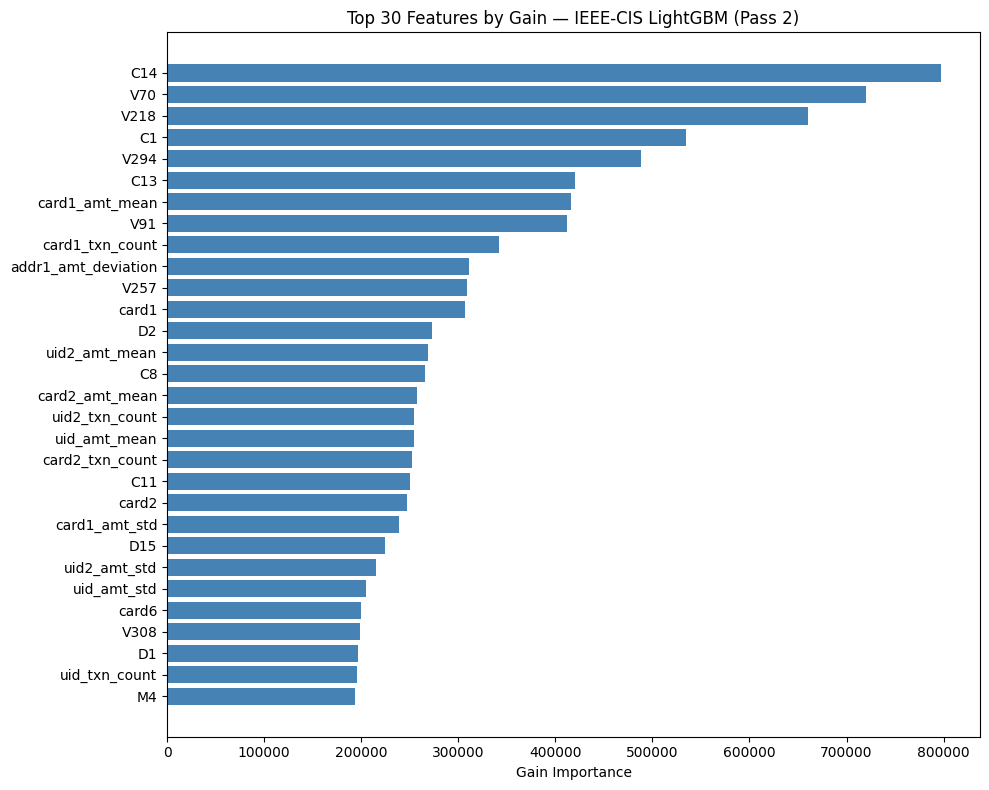

In [21]:
#Cell 9 : Feature Importance Plot
import matplotlib.pyplot as plt

top_n = 30
top_features = pd.DataFrame({
    'feature'   : model_final.feature_name(),
    'importance': model_final.feature_importance(importance_type='gain')
}).sort_values('importance', ascending=False).head(top_n)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top_features['feature'][::-1],
        top_features['importance'][::-1],
        color='steelblue')
ax.set_title(f'Top {top_n} Features by Gain — IEEE-CIS LightGBM (Pass 2)')
ax.set_xlabel('Gain Importance')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'model_feature_importance.png', dpi=120)
plt.show()


In [22]:
#Cell 10 : Save Model
model_payload = {
    'model'       : model_final,
    'feature_cols': keep_cols,
    'metrics'     : {
        'pr_auc'   : pr_auc,
        'roc_auc'  : roc_auc,
        'f1'       : f1,
        'recall'   : recall,
        'precision': precision,
        'fpr'      : fpr,
    }
}

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(model_payload, f)

print(f"✅ Model saved: {MODEL_PATH}")

# Reload sanity check
with open(MODEL_PATH, 'rb') as f:
    loaded = pickle.load(f)

test_preds = loaded['model'].predict(X_val_p2.head(5))
print(f"\nReload check — first 5 predictions: {test_preds.round(4)}")
assert loaded['feature_cols'] == keep_cols, "Feature list mismatch after reload"
print("✅ Reload verified.")



✅ Model saved: /home/minipekka/Hackathons/USM VHack 2026/nuroguard/models/lgbm_baseline_ieee.pkl

Reload check — first 5 predictions: [0.3885 0.0307 0.7732 0.9192 0.0227]
✅ Reload verified.
